In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!git clone https://github.com/razorx89/roco-dataset.git

Cloning into 'roco-dataset'...
remote: Enumerating objects: 114, done.
remote: Counting objects: 100% (23/23), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 114 (delta 7), reused 20 (delta 7), pack-reused 91 (from 1)
Receiving objects: 100% (114/114), 13.01 MiB | 8.04 MiB/s, done.
Resolving deltas: 100% (31/31), done.


CROSS CHECKING THE PATH


In [105]:
# Here we are reading the captions from a file ,removing the extra space whitespace and printing the first five captions

with open('/content/drive/MyDrive/ROCO/data/test/radiology/captions.txt', 'r') as f:
    captions = f.readlines()

captions = [caption.strip() for caption in captions]

for caption in captions[:5]:
    print(caption)


ROCO_00001	 Axial MRI (coronal view).
ROCO_00006	 Coronal plain computed tomography image showing multiple large tumor masses with edge enhancement inside the abdominal cavity and liver.
ROCO_00016	 Axial source image from an intracranial magnetic resonance angiogram reveals abnormal arterial signal elevation in the left more than right cavernous sinuses consistent with a carotid cavernous fistula, as indicated by the arrow.
ROCO_00025	 The apical height, homogeneity, and the thickness of mineral trioxide aggregate plug
ROCO_00031	 CTO of RCA (closure in the 2nd segment)


In [106]:
# Creation of DataFrame

import pandas as pd

df = pd.read_table('/content/drive/MyDrive/ROCO/data/test/radiology/captions.txt', delimiter='\t', header=None, encoding='utf-8')
print(df)

               0                                                  1
0     ROCO_00001                          Axial MRI (coronal view).
1     ROCO_00006   Coronal plain computed tomography image showi...
2     ROCO_00016   Axial source image from an intracranial magne...
3     ROCO_00025   The apical height, homogeneity, and the thick...
4     ROCO_00031            CTO of RCA (closure in the 2nd segment)
...          ...                                                ...
8174  ROCO_81771   Damus–Kaye–Stansel shunt. Oblique coronal MIP...
8175  ROCO_81778   MRI pelvis post-radiation, axial STIR/T2W FSE...
8176  ROCO_81792   Fluoroscopic image showing attempts to grab t...
8177  ROCO_81796   Positron emission tomography–computed tomogra...
8178  ROCO_81798   Cholangiography showing the metallic stent pl...

[8179 rows x 2 columns]


In [107]:

# Assigning column names
df.columns = ['Id', 'caption']

# Striped whitespaces from both columns
df['Id'] = df['Id'].str.strip()
df['caption'] = df['caption'].str.strip()

print("Revisied DataFrame:\n", df.head())


Revisied DataFrame:
            Id                                            caption
0  ROCO_00001                          Axial MRI (coronal view).
1  ROCO_00006  Coronal plain computed tomography image showin...
2  ROCO_00016  Axial source image from an intracranial magnet...
3  ROCO_00025  The apical height, homogeneity, and the thickn...
4  ROCO_00031            CTO of RCA (closure in the 2nd segment)



DATA FRAME ANALYSIS


In [108]:
import pandas as pd
import os
from PIL import Image
import matplotlib.pyplot as plt
import re
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.transforms as transforms

In [109]:

base_path= '/content/drive/MyDrive/ROCO/data'
data_splits = ['train', 'test', 'validation']
subfolders = ['radiology', 'non-radiology']
sample_size_per_category = 1000
data= []

In [110]:
# Filter out 'non-radiology' subfolder
for split in data_splits:
    for subfolder in subfolders:
        if subfolder == "non-radiology":
            continue  # Skip 'non-radiology' subfolder

        caption_file = os.path.join(base_path, split, subfolder, 'captions.txt')
        image_folder = os.path.join(base_path, split, subfolder, 'images')

        # Read a subset of captions
        with open(caption_file, 'r') as file:
            # Collect only the first `sample_size_per_category` captions
            for i, line in enumerate(file):
                if i >= sample_size_per_category:
                    break

                match = re.match(r"^(\S+)\s+(.*)$", line.strip())
                if match:
                    image_id = match.group(1)
                    caption = match.group(2)
                    image_path = os.path.join(image_folder, f"{image_id}.jpg")

                    # Append data entry to list
                    data.append({
                        'image_id': image_id,
                        'caption': caption,
                        'label': subfolder,
                        'split': split,
                        'image_path': image_path
                    })


In [111]:

sample_df = pd.DataFrame(data)
print("Sample DataFrame created with columns:", sample_df.columns)

Sample DataFrame created with columns: Index(['image_id', 'caption', 'label', 'split', 'image_path'], dtype='object')


In [112]:
print(sample_df.sample(n=5))

        image_id                                            caption  \
528   ROCO_00667  Intravenous pyelogram showing absent right kid...   
1978  ROCO_09966  23-year-old female presented with painless swe...   
1102  ROCO_01123  CT scan portal phase. After contrast enhanceme...   
1003  ROCO_00025  The apical height, homogeneity, and the thickn...   
526   ROCO_00665  Contrast Enhanced computed tomography scan of ...   

          label  split                                         image_path  
528   radiology  train  /content/drive/MyDrive/ROCO/data/train/radiolo...  
1978  radiology   test  /content/drive/MyDrive/ROCO/data/test/radiolog...  
1102  radiology   test  /content/drive/MyDrive/ROCO/data/test/radiolog...  
1003  radiology   test  /content/drive/MyDrive/ROCO/data/test/radiolog...  
526   radiology  train  /content/drive/MyDrive/ROCO/data/train/radiolo...  


In [113]:
# Checking any missed values

missing_values = sample_df.isnull().sum()
print("Missing Values in each column:\n", missing_values)


Missing Values in each column:
 image_id      0
caption       0
label         0
split         0
image_path    0
dtype: int64


In [114]:
#checking for the Duplicates

duplicate_rows = sample_df[sample_df.duplicated()]
print(f"Number of duplicate rows: {duplicate_rows.shape[0]}")

Number of duplicate rows: 0


In [115]:
# Calculate the word count for each caption
sample_df['caption_word_count'] = sample_df['caption'].apply(lambda x: len(x.split()))

#Count of words on average
average_word_count = sample_df['caption_word_count'].mean()

print(f"Average word count of captions: {round(average_word_count, 2)}")


Average word count of captions: 19.99


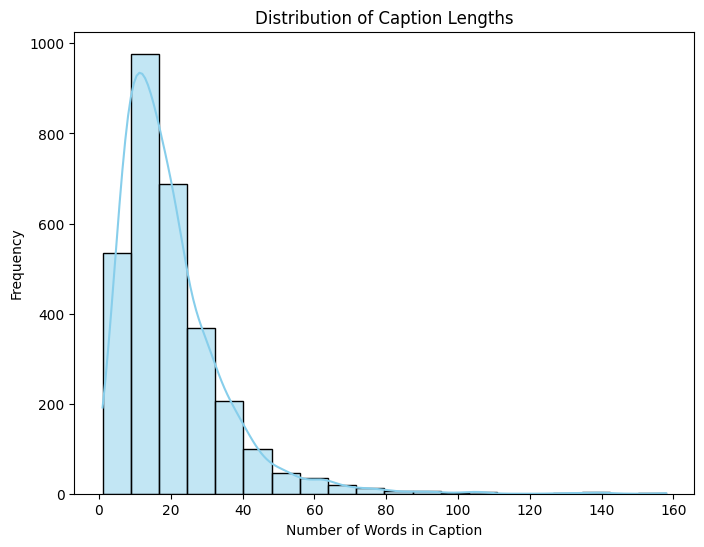

In [116]:
import seaborn as sns

# Plot a histogram of caption word counts
plt.figure(figsize=(8, 6))
sns.histplot(sample_df['caption_word_count'],kde =True ,bins=20, color='skyblue')
plt.title("Distribution of Caption Lengths")
plt.xlabel("Number of Words in Caption")
plt.ylabel("Frequency")
plt.show()


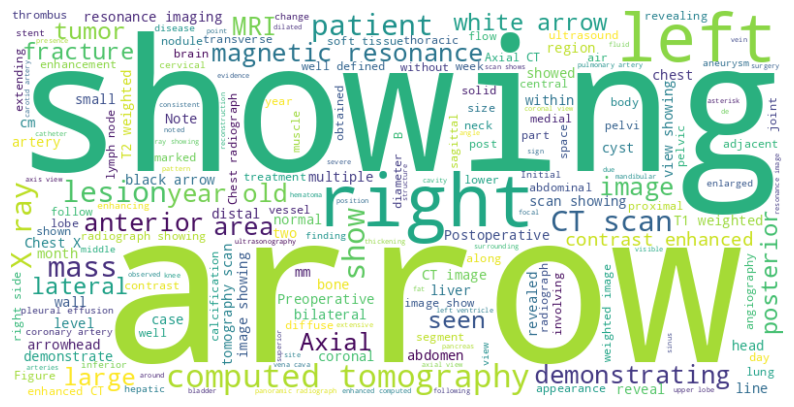

In [117]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Join all captions into a single string
text = " ".join(sample_df['caption'])

# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

# Display the word cloud
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()


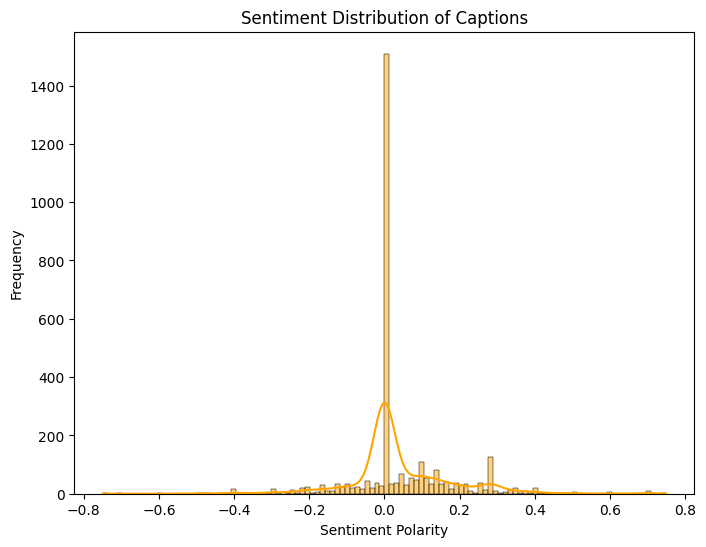

In [118]:
from textblob import TextBlob
# Polarity: This measures the sentiment of the text on a scale from -1 to 1.
# -1 means a negative sentiment.
#  0 means a neutral sentiment.
#  1 means a positive sentiment."""

# Perform sentiment analysis on each caption
sample_df['sentiment'] = sample_df['caption'].apply(lambda x: TextBlob(x).sentiment.polarity)

plt.figure(figsize=(8, 6))
sns.histplot(sample_df['sentiment'], kde=True, color='orange')
plt.title("Sentiment Distribution of Captions")
plt.xlabel("Sentiment Polarity")
plt.ylabel("Frequency")
plt.show()


In [119]:

import pandas as pd
from PIL import Image
from IPython.display import Image as IPImage, display
import os

In [120]:

def load_image_for_display(image_path):
    # Return an IPImage that will be shown in Notebooks
    return IPImage(filename=image_path)

In [121]:

sample_df_limited =sample_df.sample(n=3)

In [122]:

image_paths = []
captions = []

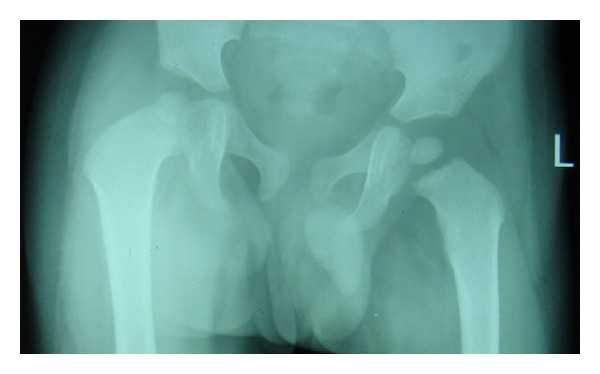

Caption: Septic arthritis of left hip showing increased joint space.



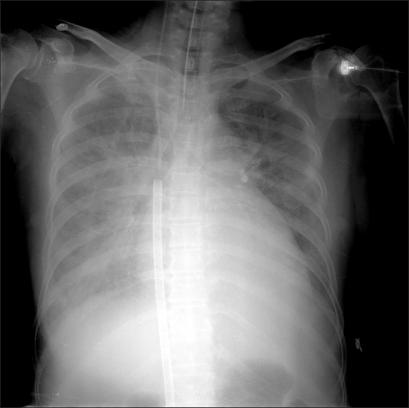

Caption: Preoperative chest X-ray (case 1) showing ECMO catheter and pulmonary venous congestion. ECMO=Extracorporeal membrane oxygenation.



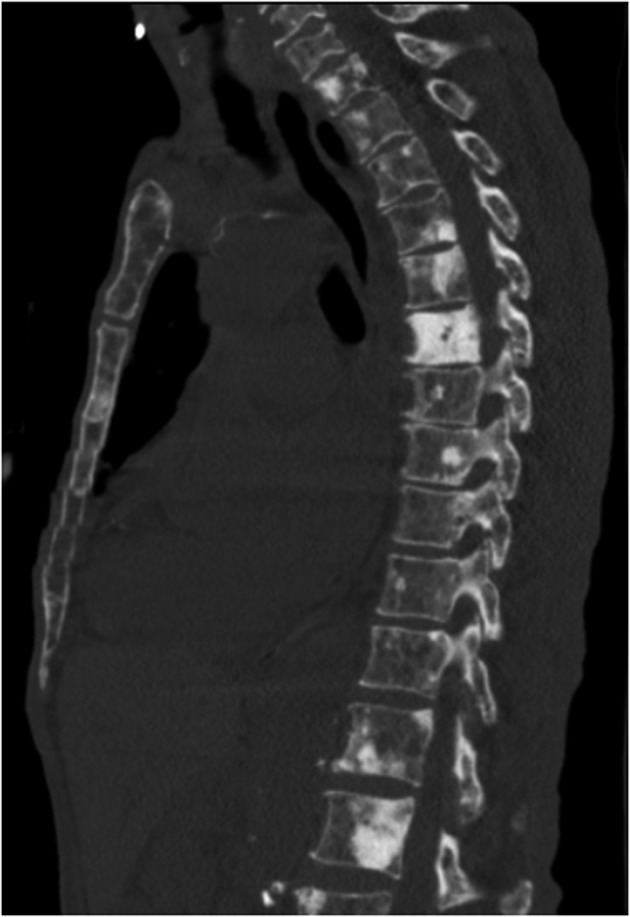

Caption: Reconstruction images of the CT chest showing multiple osteoblastic lesions in thoraco-lumbar vertebrae.



In [123]:
for index, row in sample_df_limited.iterrows():
    image_id = row['image_id']
    caption = row['caption']
    split = row['split']
    label = row['label']

    image_path = os.path.join(base_path, split, label, 'images', f"{image_id}.jpg")

    # Display the image using IPython's Image function
    image_path = os.path.join( base_path, split, label, 'images', f"{image_id}.jpg")

    # Display the image using IPython's Image function
    display(IPImage(filename=image_path))

    # Display the caption for that image
    print(f"Caption: {caption}\n")

# Preprocessing Techniques

In [124]:
img_dir="/content/drive/MyDrive/ROCO/data/train/radiology/images"

In [125]:
import cv2
import numpy as np
import os

In [126]:
ima_files =[f for f in os.listdir(img_dir) if f.endswith(".jpg")]

In [127]:
ima_files

['ROCO_73483.jpg',
 'ROCO_73492.jpg',
 'ROCO_73496.jpg',
 'ROCO_73498.jpg',
 'ROCO_73505.jpg',
 'ROCO_73506.jpg',
 'ROCO_73521.jpg',
 'ROCO_73518.jpg',
 'ROCO_73534.jpg',
 'ROCO_73548.jpg',
 'ROCO_73555.jpg',
 'ROCO_73554.jpg',
 'ROCO_78382.jpg',
 'ROCO_73557.jpg',
 'ROCO_73568.jpg',
 'ROCO_73574.jpg',
 'ROCO_73589.jpg',
 'ROCO_73593.jpg',
 'ROCO_73594.jpg',
 'ROCO_73597.jpg',
 'ROCO_73611.jpg',
 'ROCO_73619.jpg',
 'ROCO_73627.jpg',
 'ROCO_73629.jpg',
 'ROCO_73631.jpg',
 'ROCO_74096.jpg',
 'ROCO_73681.jpg',
 'ROCO_73687.jpg',
 'ROCO_75955.jpg',
 'ROCO_73707.jpg',
 'ROCO_73717.jpg',
 'ROCO_73727.jpg',
 'ROCO_73744.jpg',
 'ROCO_73743.jpg',
 'ROCO_73757.jpg',
 'ROCO_73772.jpg',
 'ROCO_73775.jpg',
 'ROCO_73780.jpg',
 'ROCO_73807.jpg',
 'ROCO_73826.jpg',
 'ROCO_73834.jpg',
 'ROCO_73881.jpg',
 'ROCO_73889.jpg',
 'ROCO_73909.jpg',
 'ROCO_73912.jpg',
 'ROCO_73927.jpg',
 'ROCO_73934.jpg',
 'ROCO_79706.jpg',
 'ROCO_73945.jpg',
 'ROCO_73955.jpg',
 'ROCO_73956.jpg',
 'ROCO_73973.jpg',
 'ROCO_73975

In [128]:
img_path = os.path.join(img_dir,ima_files[4444])
img_path1 = os.path.join(img_dir,ima_files[144])


In [129]:
print(img_path)
print(img_path1)

/content/drive/MyDrive/ROCO/data/train/radiology/images/ROCO_51846.jpg
/content/drive/MyDrive/ROCO/data/train/radiology/images/ROCO_74751.jpg


In [130]:
img =cv2.imread(img_path)
img1 =cv2.imread(img_path1)

array([[[53, 31, 26],
        [54, 34, 23],
        [58, 36, 18],
        ...,
        [37, 26, 22],
        [39, 28, 24],
        [35, 26, 22]],

       [[55, 32, 24],
        [57, 36, 21],
        [62, 41, 19],
        ...,
        [31, 19, 15],
        [34, 23, 19],
        [33, 22, 18]],

       [[59, 36, 20],
        [63, 42, 20],
        [68, 48, 17],
        ...,
        [28, 16, 12],
        [32, 21, 17],
        [33, 22, 18]],

       ...,

       [[53, 33, 16],
        [58, 36, 18],
        [62, 38, 18],
        ...,
        [40, 22, 15],
        [41, 23, 16],
        [40, 24, 18]],

       [[53, 33, 16],
        [55, 35, 18],
        [59, 37, 19],
        ...,
        [40, 24, 18],
        [40, 24, 18],
        [40, 23, 20]],

       [[50, 32, 15],
        [55, 35, 18],
        [58, 36, 18],
        ...,
        [40, 24, 18],
        [40, 24, 18],
        [38, 21, 18]]], dtype=uint8)
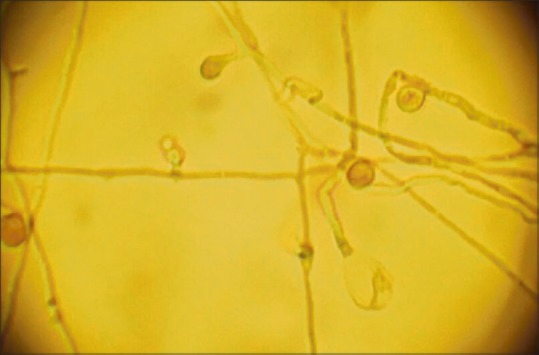

In [131]:
img

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
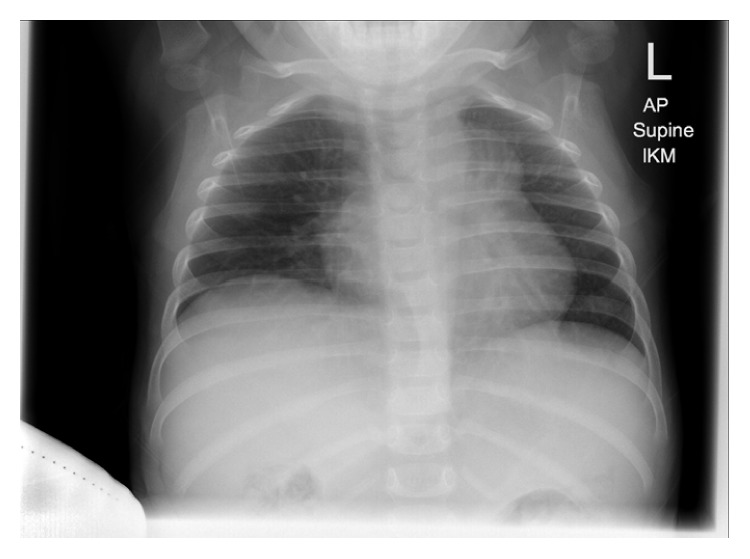

In [132]:
img1

array([[[54, 33, 23],
        [61, 42, 11],
        [69, 50, 10],
        ...,
        [42, 26, 19],
        [37, 24, 20],
        [37, 26, 22]],

       [[61, 40, 20],
        [71, 53, 12],
        [80, 60, 13],
        ...,
        [38, 20, 13],
        [33, 19, 13],
        [32, 21, 17]],

       [[66, 45, 15],
        [76, 57, 10],
        [78, 56,  4],
        ...,
        [42, 20, 12],
        [36, 18, 12],
        [36, 23, 19]],

       ...,

       [[55, 34, 16],
        [71, 43, 15],
        [78, 45, 10],
        ...,
        [56, 27,  5],
        [47, 23,  6],
        [42, 24, 15]],

       [[56, 35, 17],
        [63, 39, 17],
        [69, 39, 15],
        ...,
        [49, 25, 12],
        [42, 21, 13],
        [40, 23, 17]],

       [[54, 34, 17],
        [60, 36, 18],
        [63, 38, 17],
        ...,
        [48, 27, 16],
        [43, 25, 17],
        [39, 23, 18]]], dtype=uint8)
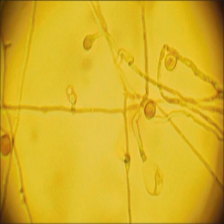

In [133]:
target_size=(224,224)
cv2.resize(img,target_size)

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
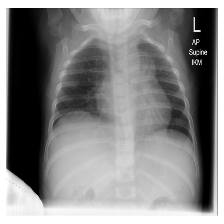

In [134]:
target_size1 =(224,224)
cv2.resize(img1,target_size)

In [135]:
img_processed = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

In [136]:
img_processed1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)

In [137]:
img_normalised = img/255
img_normalised

array([[[0.20784314, 0.12156863, 0.10196078],
        [0.21176471, 0.13333333, 0.09019608],
        [0.22745098, 0.14117647, 0.07058824],
        ...,
        [0.14509804, 0.10196078, 0.08627451],
        [0.15294118, 0.10980392, 0.09411765],
        [0.1372549 , 0.10196078, 0.08627451]],

       [[0.21568627, 0.1254902 , 0.09411765],
        [0.22352941, 0.14117647, 0.08235294],
        [0.24313725, 0.16078431, 0.0745098 ],
        ...,
        [0.12156863, 0.0745098 , 0.05882353],
        [0.13333333, 0.09019608, 0.0745098 ],
        [0.12941176, 0.08627451, 0.07058824]],

       [[0.23137255, 0.14117647, 0.07843137],
        [0.24705882, 0.16470588, 0.07843137],
        [0.26666667, 0.18823529, 0.06666667],
        ...,
        [0.10980392, 0.0627451 , 0.04705882],
        [0.1254902 , 0.08235294, 0.06666667],
        [0.12941176, 0.08627451, 0.07058824]],

       ...,

       [[0.20784314, 0.12941176, 0.0627451 ],
        [0.22745098, 0.14117647, 0.07058824],
        [0.24313725, 0

In [138]:
# Applying histogram equalization and denoising

img_eq = cv2.equalizeHist(img_processed.squeeze())
print(f"Equalized Image (first 5 pixels): {img_eq[:5, :5]}")

img_denoised = cv2.GaussianBlur(img_eq, (5, 5), 0)
print(f"Denoised Image (first 5 pixels): {img_denoised[:5, :5]}")

Equalized Image (first 5 pixels): [[1 1 1 1 1]
 [1 1 1 1 2]
 [1 1 2 2 2]
 [1 1 2 2 2]
 [1 1 2 2 2]]
Denoised Image (first 5 pixels): [[1 1 1 1 2]
 [1 1 1 1 2]
 [1 1 1 2 2]
 [1 1 2 2 2]
 [1 1 2 2 2]]


In [139]:
img_eq1 = cv2.equalizeHist(img_processed1.squeeze())
print(f"Equalized Image 1 (first 5 pixels): {img_eq1[:5, :5]}")

img_denoised1 = cv2.GaussianBlur(img_eq1, (5, 5), 0)
print(f"Denoised Image 1 (first 5 pixels): {img_denoised1[:5, :5]}")

Equalized Image 1 (first 5 pixels): [[255 255 255 255 255]
 [255 255 255 255 255]
 [255 255 255 255 255]
 [255 255 255 255 255]
 [255 255 255 255 255]]
Denoised Image 1 (first 5 pixels): [[255 255 255 255 255]
 [255 255 255 255 255]
 [255 255 255 255 255]
 [255 255 255 255 255]
 [255 255 255 255 255]]


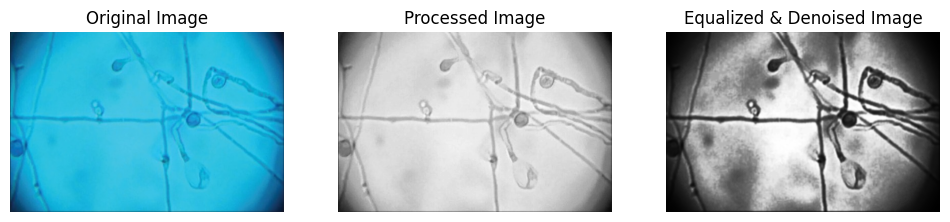

In [140]:
# Visualize the original, preprocessed, and denoised images
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Original Image
plt.subplot(1, 3, 1)
img_original = cv2.imread(img_path)
plt.imshow(cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

# Processed Image (Grayscale & Normalized)
plt.subplot(1, 3, 2)
plt.imshow(img_processed.squeeze(), cmap='gray')
plt.title('Processed Image')
plt.axis('off')

# Equalized and Denoised Image (Optional)
plt.subplot(1, 3, 3)
plt.imshow(img_denoised, cmap='gray')
plt.title('Equalized & Denoised Image')
plt.axis('off')

plt.show()

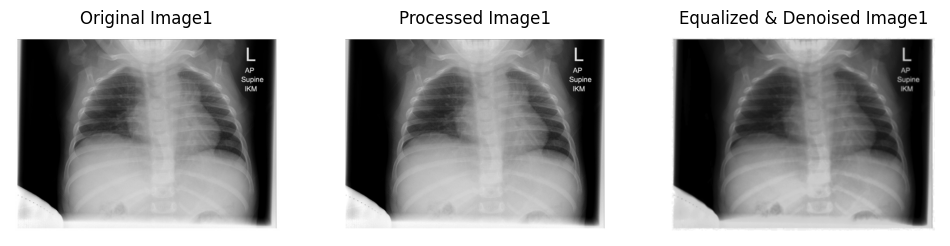

In [141]:
# Visualize the original, preprocessed, and denoised images
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Original Image
plt.subplot(1, 3, 1)
img_original1 = cv2.imread(img_path1)
plt.imshow(cv2.cvtColor(img_original1, cv2.COLOR_BGR2RGB))
plt.title('Original Image1')
plt.axis('off')

# Processed Image (Grayscale & Normalized)
plt.subplot(1, 3, 2)
plt.imshow(img_processed1.squeeze(), cmap='gray')
plt.title('Processed Image1')
plt.axis('off')

# Equalized and Denoised Image (Optional)
plt.subplot(1, 3, 3)
plt.imshow(img_denoised1, cmap='gray')
plt.title('Equalized & Denoised Image1')
plt.axis('off')

plt.show()

In [142]:
import tensorflow as tf



In [143]:
img=np.expand_dims(img,axis=0)
img1=np.expand_dims(img1,axis=0)


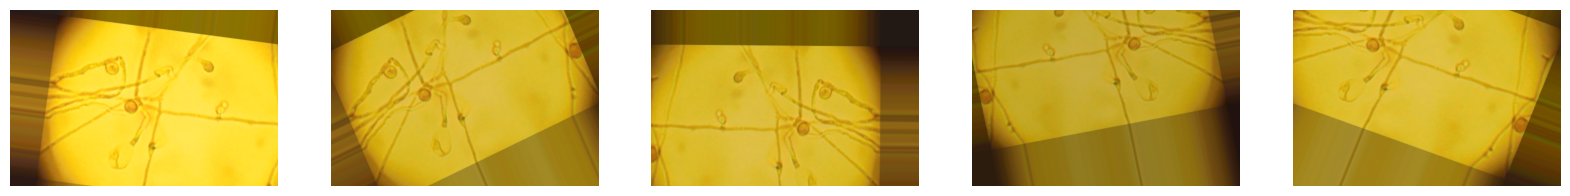

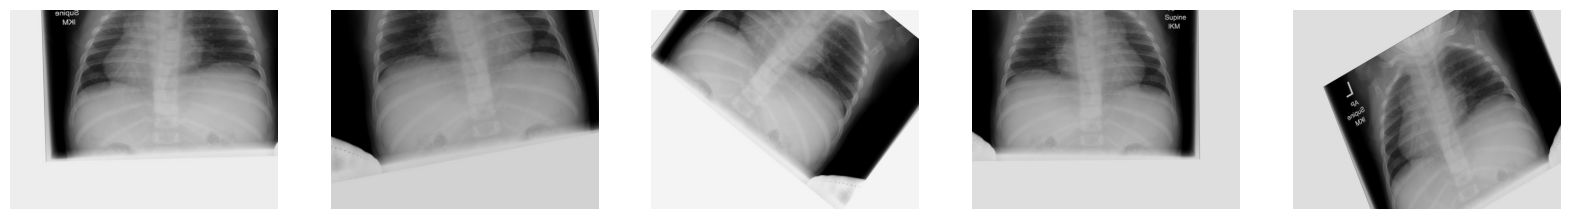

In [144]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define more diverse augmentation settings
datagen = ImageDataGenerator(
    rotation_range=40,            # Randomly rotate images within 40 degrees
    width_shift_range=0.2,        # Shift images horizontally by 20% of the width
    height_shift_range=0.2,       # Shift images vertically by 20% of the height
    shear_range=0.2,              # Shear transformation with a shear intensity of 20%
    zoom_range=0.2,               # Randomly zoom in on images by 20%
    brightness_range=[0.8, 1.2],  # Randomly adjust brightness
    horizontal_flip=True,         # Randomly flip images horizontally
    fill_mode='nearest'           # Fill pixels that are outside the boundaries
)

# Apply augmentation to a single image
augmented_images = [next(datagen.flow(img, batch_size=1))[0] for _ in range(5)]

# Display augmented images
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 5))
for i, aug_img in enumerate(augmented_images):
    plt.subplot(1, 5, i + 1)
    plt.imshow(aug_img.astype('uint8'))
    plt.axis('off')
plt.show()


augmented_images1 = [next(datagen.flow(img1, batch_size=1))[0] for _ in range(5)]

# Display augmented images
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 5))
for i, aug_img1 in enumerate(augmented_images1):
    plt.subplot(1, 5, i + 1)
    plt.imshow(aug_img1.astype('uint8'))
    plt.axis('off')
plt.show()


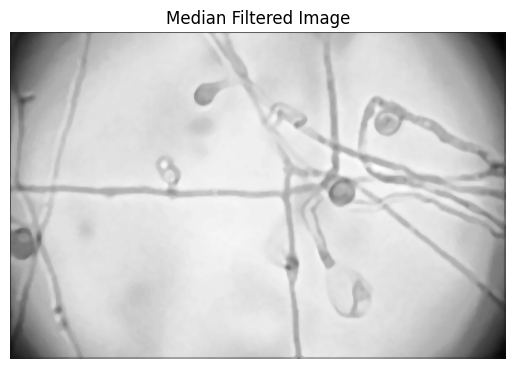

In [145]:
# Apply median filtering
img_median = cv2.medianBlur(img_processed, 5)  # Adjust kernel size (5x5)

# Display result
plt.imshow(img_median, cmap='gray')
plt.title("Median Filtered Image")
plt.axis('off')
plt.show()


In [146]:
#Convert images to tensors using libraries like TensorFlow or PyTorch, as most deep learning models work with tensor data.

import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
image_array = img_to_array(img_processed)

# Convert numpy array to tensor
image_tensor = tf.convert_to_tensor(image_array)

# Optionally, add a batch dimension if you need it (e.g., for model inference)
image_tensor = tf.expand_dims(image_tensor, axis=0)
# Normalize pixel values to [0, 1] if required
image_tensor = image_tensor / 255.0
print(image_tensor)

tf.Tensor(
[[[[0.1254902 ]
   [0.12941177]
   [0.12941177]
   ...
   [0.10196079]
   [0.10980392]
   [0.10196079]]

  [[0.1254902 ]
   [0.13333334]
   [0.14509805]
   ...
   [0.07450981]
   [0.09019608]
   [0.08627451]]

  [[0.13333334]
   [0.14901961]
   [0.16078432]
   ...
   [0.0627451 ]
   [0.08235294]
   [0.08627451]]

  ...

  [[0.11764706]
   [0.12941177]
   [0.13725491]
   ...
   [0.08627451]
   [0.09019608]
   [0.09411765]]

  [[0.11764706]
   [0.1254902 ]
   [0.13333334]
   ...
   [0.09411765]
   [0.09411765]
   [0.09411765]]

  [[0.11372549]
   [0.1254902 ]
   [0.12941177]
   ...
   [0.09411765]
   [0.09411765]
   [0.08627451]]]], shape=(1, 355, 539, 1), dtype=float32)


In [147]:
# For Image1

image_array1 = img_to_array(img_processed1)

# Convert numpy array to tensor
image_tensor1 = tf.convert_to_tensor(image_array1)

# Optionally, add a batch dimension if you need it (e.g., for model inference)
image_tensor1 = tf.expand_dims(image_tensor1, axis=0)
# Normalize pixel values to [0, 1] if required
image_tensor1 = image_tensor1 / 255.0
print(image_tensor1)

tf.Tensor(
[[[[1.]
   [1.]
   [1.]
   ...
   [1.]
   [1.]
   [1.]]

  [[1.]
   [1.]
   [1.]
   ...
   [1.]
   [1.]
   [1.]]

  [[1.]
   [1.]
   [1.]
   ...
   [1.]
   [1.]
   [1.]]

  ...

  [[1.]
   [1.]
   [1.]
   ...
   [1.]
   [1.]
   [1.]]

  [[1.]
   [1.]
   [1.]
   ...
   [1.]
   [1.]
   [1.]]

  [[1.]
   [1.]
   [1.]
   ...
   [1.]
   [1.]
   [1.]]]], shape=(1, 559, 750, 1), dtype=float32)


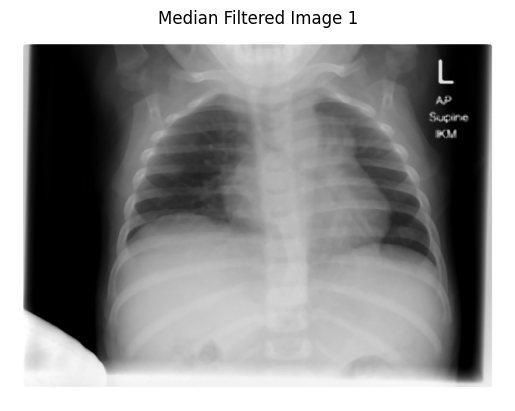

In [148]:
# Apply median filtering
img_median1 = cv2.medianBlur(img_processed1, 5)  # Adjust kernel size (5x5)

# Display result
plt.imshow(img_median1, cmap='gray')
plt.title("Median Filtered Image 1")
plt.axis('off')
plt.show()

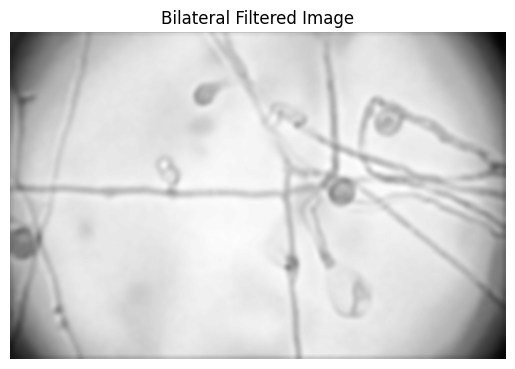

In [149]:
# Apply bilateral filtering
img_bilateral = cv2.bilateralFilter(img_processed, d=9, sigmaColor=75, sigmaSpace=75)

# Display result
plt.imshow(img_bilateral, cmap='gray')
plt.title("Bilateral Filtered Image")
plt.axis('off')
plt.show()


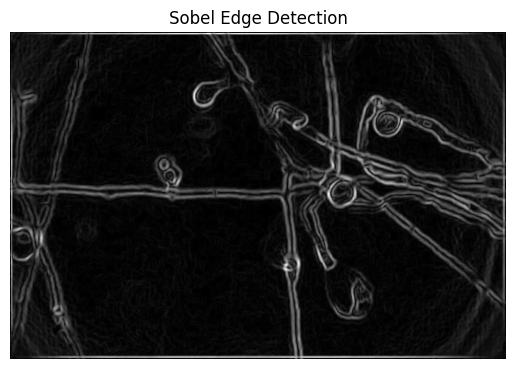

In [150]:
# Apply Sobel edge detection on the grayscale image
sobel_x = cv2.Sobel(img_processed, cv2.CV_64F, 1, 0, ksize=5)  # Horizontal edges
sobel_y = cv2.Sobel(img_processed, cv2.CV_64F, 0, 1, ksize=5)  # Vertical edges

# Combine edges
sobel_combined = cv2.magnitude(sobel_x, sobel_y)

# Display result
plt.imshow(sobel_combined, cmap='gray')
plt.title("Sobel Edge Detection")
plt.axis('off')
plt.show()


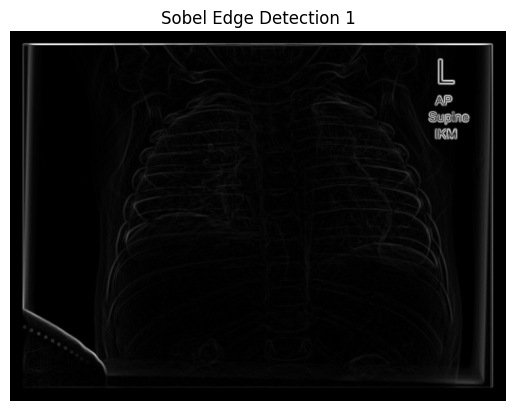

In [151]:
# Apply Sobel edge detection on the grayscale image
sobel_x1 = cv2.Sobel(img_processed1, cv2.CV_64F, 1, 0, ksize=5)  # Horizontal edges
sobel_y1 = cv2.Sobel(img_processed1, cv2.CV_64F, 0, 1, ksize=5)  # Vertical edges

# Combine edges
sobel_combined1 = cv2.magnitude(sobel_x1, sobel_y1)

# Display result
plt.imshow(sobel_combined1, cmap='gray')
plt.title("Sobel Edge Detection 1")
plt.axis('off')
plt.show()

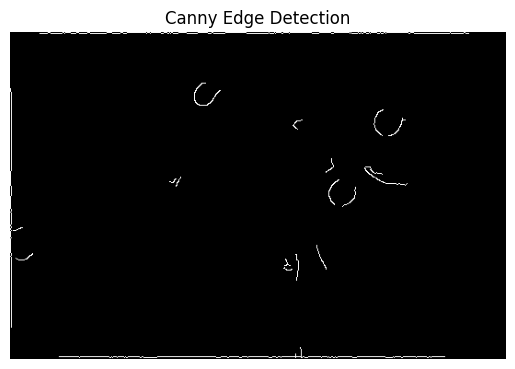

In [152]:
# Apply Canny edge detection
edges = cv2.Canny(img_processed, threshold1=100, threshold2=200)

# Display result
plt.imshow(edges, cmap='gray')
plt.title("Canny Edge Detection")
plt.axis('off')
plt.show()


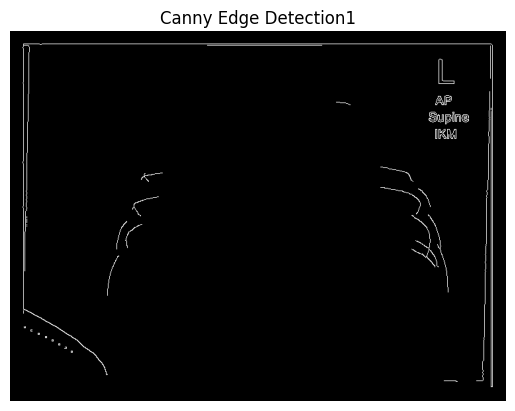

In [153]:
# Apply Canny edge detection
edges1 = cv2.Canny(img_processed1, threshold1=100, threshold2=200)

# Display result
plt.imshow(edges1, cmap='gray')
plt.title("Canny Edge Detection1")
plt.axis('off')
plt.show()

In [154]:

sample_df['caption'].sample(5, random_state=42)


,caption
1801,Plain radiograph of the cervical spine in pati...
1190,Measurement of the laminar angle and length (A...
1817,Axial T2 Weighted Image – Translational atlant...
251,Computed tomography scan interpreted as cholel...
2505,Lesions in the right posterior temporal–pariet...


In [155]:
import re
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import nltk
from nltk.stem import SnowballStemmer

In [156]:

nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('wordnet')
snowballstemmer=SnowballStemmer('english')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [157]:

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()


In [158]:

def preprocess_caption(caption):
    # Lowercase
    caption = caption.lower()

    # Remove punctuation
    caption = re.sub(f"[{string.punctuation}]", "", caption)

    # Tokenize
    tokens = word_tokenize(caption)

    # Remove stop words
    tokens = [word for word in tokens if word not in stop_words]

    #stemming
    tokens= [snowballstemmer.stem(word) for word in tokens]

    # Lemmatize
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # Join tokens back into a cleaned caption
    cleaned_caption = " ".join(tokens)
    return cleaned_caption

In [159]:
sample_df['cleaned_caption'] = sample_df['caption'].apply(preprocess_caption)


In [160]:

sample_df['cleaned_caption'].sample(5, random_state=42)


,cleaned_caption
1801,plain radiograph cervic spine patient 2 reveal...
1190,measur laminar angl length ab
1817,axial t2 weight imag – translat atlantoaxi sublux
251,comput tomographi scan interpret cholelithiasi...
2505,lesion right posterior temporal–pariet region


In [161]:

from nltk import word_tokenize, pos_tag, ne_chunk

In [162]:
nltk.download('averaged_perceptron_tagger_eng')
nltk.download("maxent_ne_chunker")
nltk.download("words")
nltk.download("maxent_ne_chunker_tab")

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker.zip.
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.
[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker_tab.zip.


True

In [163]:
size = sample_df['cleaned_caption'].size
print(size)


3000


In [164]:
new_df = sample_df.sample(n=10, random_state=42)


In [165]:
ner_tags = []

for caption in new_df['cleaned_caption']:
    tokens = word_tokenize(caption)  # Tokenize the caption
    tags = nltk.pos_tag(tokens)      # POS tagging is needed for NER
    entities = nltk.ne_chunk(tags)  # Get NER tags
    ner_tags.append(entities)

In [166]:
ner_tags

[Tree('S', [('plain', 'NN'), ('radiograph', 'NN'), ('cervic', 'JJ'), ('spine', 'NN'), ('patient', 'NN'), ('2', 'CD'), ('reveal', 'NN'), ('levin', 'JJ'), ('edward', 'NN'), ('type', 'NN'), ('iii', 'NN'), ('hangman', 'NN'), ('fractur', 'NN')]),
 Tree('S', [('measur', 'NN'), ('laminar', 'NN'), ('angl', 'NN'), ('length', 'NN'), ('ab', 'NN')]),
 Tree('S', [('axial', 'JJ'), ('t2', 'NN'), ('weight', 'VBD'), ('imag', 'JJ'), ('–', 'NNP'), ('translat', 'NN'), ('atlantoaxi', 'NN'), ('sublux', 'NN')]),
 Tree('S', [('comput', 'NN'), ('tomographi', 'NNS'), ('scan', 'JJ'), ('interpret', 'JJ'), ('cholelithiasi', 'NN'), ('despit', 'NN'), ('previous', 'JJ'), ('cholecystectomi', 'NN'), ('doubl', 'NN'), ('arrow', 'NN'), ('point', 'NN'), ('extrabiliari', 'VBP'), ('gallston', 'NN')]),
 Tree('S', [('lesion', 'NN'), ('right', 'RB'), ('posterior', 'JJ'), ('temporal–pariet', 'JJ'), ('region', 'NN')]),
 Tree('S', [('aortogram', 'JJ'), ('reveal', 'NN'), ('sever', 'RB'), ('aortic', 'JJ'), ('regurgit', 'NN'), ('poss

In [167]:
# Randomly select 20 captions
random_captions = sample_df['caption'].sample(n=25, random_state=42)

# Combine the selected captions into a single paragraph
combined_captions = " ".join(random_captions)

print(combined_captions)

Plain radiograph of the cervical spine in patient 2 revealing a Levine and Edwards type III Hangman's fracture Measurement of the laminar angle and length (A,B). Axial T2 Weighted Image – Translational atlanto-axial subluxation. Computed tomography scan interpreted as cholelithiasis, despite a previous cholecystectomy. Double arrows point to extrabiliary gallstones. Lesions in the right posterior temporal–parietal region. Aortogram revealing severe aortic regurgitation with possible dissection flap. CXR on initial presentation at other district general hospital. Fat suppressed magnetic resonance imaging demonstrating edema in the cervical spinal cord as a result of root avulsion. Magnetic resonance imaging (MRI) of the abdominal mass Six months follow-up radiograph Preoperative radiograph Catch of the muscles with 5.0 non-resorbable suture thread and their resection near the insertion; Eye prosthesis made up of a Polymethyl methacrylate) (PMMA) ball covered with a Polyethylene terephth

TEXT CLEANING


In [168]:
combined_captions = combined_captions.lower()

In [169]:
print(combined_captions)

plain radiograph of the cervical spine in patient 2 revealing a levine and edwards type iii hangman's fracture measurement of the laminar angle and length (a,b). axial t2 weighted image – translational atlanto-axial subluxation. computed tomography scan interpreted as cholelithiasis, despite a previous cholecystectomy. double arrows point to extrabiliary gallstones. lesions in the right posterior temporal–parietal region. aortogram revealing severe aortic regurgitation with possible dissection flap. cxr on initial presentation at other district general hospital. fat suppressed magnetic resonance imaging demonstrating edema in the cervical spinal cord as a result of root avulsion. magnetic resonance imaging (mri) of the abdominal mass six months follow-up radiograph preoperative radiograph catch of the muscles with 5.0 non-resorbable suture thread and their resection near the insertion; eye prosthesis made up of a polymethyl methacrylate) (pmma) ball covered with a polyethylene terephth

STOP WORDS

In [170]:
from nltk.corpus import stopwords

In [171]:
import nltk
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [172]:
stop_words=set(stopwords.words('english'))

In [173]:
print(stop_words)

{'same', 'myself', 'only', 's', 'have', 'haven', 'what', 'an', 'into', 'if', 'them', 'here', 'when', 'was', "isn't", 'some', 'too', 'has', 'more', 'below', 'out', 'and', 'other', "hasn't", 'their', "shouldn't", 'ours', 'weren', 'having', "hadn't", 'itself', 'until', "you've", 'him', 'that', 'through', 'both', "you're", 'not', 'for', 'me', 'won', 'before', "wouldn't", 'this', 'm', 'can', 'how', 'or', 'mustn', 'where', 'shan', 'do', 'by', 'had', 'because', 'i', 'above', 'further', 've', 'been', "didn't", 'on', 'theirs', 'once', 'about', 'wasn', 'd', 'don', 'from', 'whom', 'down', 'herself', 'such', 'to', 'aren', "shan't", 'over', 'between', 'ourselves', "you'll", 'our', 'against', 'with', 'is', 'than', "that'll", 'hers', 'wouldn', 'in', 'didn', 'under', 'are', "aren't", 'then', 'her', "doesn't", 'shouldn', 'yourselves', 'his', "couldn't", 'y', 're', 'very', 'hadn', 'after', 'nor', 'were', 'my', 'a', 'while', 'o', 'why', 'needn', 'those', 'yours', 'during', 'will', 'your', 'doesn', 'being

In [174]:
text_input=" ".join([word for word in combined_captions.split() if word not in stop_words])

In [175]:
print(text_input)

plain radiograph cervical spine patient 2 revealing levine edwards type iii hangman's fracture measurement laminar angle length (a,b). axial t2 weighted image – translational atlanto-axial subluxation. computed tomography scan interpreted cholelithiasis, despite previous cholecystectomy. double arrows point extrabiliary gallstones. lesions right posterior temporal–parietal region. aortogram revealing severe aortic regurgitation possible dissection flap. cxr initial presentation district general hospital. fat suppressed magnetic resonance imaging demonstrating edema cervical spinal cord result root avulsion. magnetic resonance imaging (mri) abdominal mass six months follow-up radiograph preoperative radiograph catch muscles 5.0 non-resorbable suture thread resection near insertion; eye prosthesis made polymethyl methacrylate) (pmma) ball covered polyethylene terephthalate shell (dacron) occlusion cholangiogram cystic duct stone removal. high parasternal view. ultrasound beam intermediat

In [176]:
from textblob import TextBlob

In [177]:
TextBlob(text_input).correct()

TextBlob("plain radiogram cervical spine patient 2 revealing line edwards type iii hangman's fracture measurement lamina angle length (a,b). animal to weighted image – translation atlanta-animal subjugation. computer cosmography scan interpreted cholelithiasis, despite previous cholecystectomy. double arrows point extrabiliary gallstones. lesions right posterior temporal–parietal region. aortogram revealing severe aortic regurgitation possible dissection flap. car initial presentation district general hospital. fat suppressed magnetic resonance imagine demonstrating oedema cervical spinal cord result root avulsion. magnetic resonance imagine (mr) abdominal mass six months follow-up radiogram preoperative radiogram catch muscles 5.0 non-absorbable suture thread resection near insertion; eye prosthesis made polymethyl methacrylate) (emma) ball covered polyethylene terephthalate shell (dron) occlusion cholangiogram cystic duct stone removal. high parasternal view. ultrasound beam intermed

TOKENIZATION

In [178]:
from nltk.tokenize import sent_tokenize

In [179]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [180]:
combined_caption = sent_tokenize(combined_captions)

In [181]:
sent_tokenize(combined_captions)

["plain radiograph of the cervical spine in patient 2 revealing a levine and edwards type iii hangman's fracture measurement of the laminar angle and length (a,b).",
 'axial t2 weighted image – translational atlanto-axial subluxation.',
 'computed tomography scan interpreted as cholelithiasis, despite a previous cholecystectomy.',
 'double arrows point to extrabiliary gallstones.',
 'lesions in the right posterior temporal–parietal region.',
 'aortogram revealing severe aortic regurgitation with possible dissection flap.',
 'cxr on initial presentation at other district general hospital.',
 'fat suppressed magnetic resonance imaging demonstrating edema in the cervical spinal cord as a result of root avulsion.',
 'magnetic resonance imaging (mri) of the abdominal mass six months follow-up radiograph preoperative radiograph catch of the muscles with 5.0 non-resorbable suture thread and their resection near the insertion; eye prosthesis made up of a polymethyl methacrylate) (pmma) ball co

In [182]:
print(combined_caption)

["plain radiograph of the cervical spine in patient 2 revealing a levine and edwards type iii hangman's fracture measurement of the laminar angle and length (a,b).", 'axial t2 weighted image – translational atlanto-axial subluxation.', 'computed tomography scan interpreted as cholelithiasis, despite a previous cholecystectomy.', 'double arrows point to extrabiliary gallstones.', 'lesions in the right posterior temporal–parietal region.', 'aortogram revealing severe aortic regurgitation with possible dissection flap.', 'cxr on initial presentation at other district general hospital.', 'fat suppressed magnetic resonance imaging demonstrating edema in the cervical spinal cord as a result of root avulsion.', 'magnetic resonance imaging (mri) of the abdominal mass six months follow-up radiograph preoperative radiograph catch of the muscles with 5.0 non-resorbable suture thread and their resection near the insertion; eye prosthesis made up of a polymethyl methacrylate) (pmma) ball covered wi

In [183]:
## Word Punctuation token

In [184]:
from nltk.tokenize import wordpunct_tokenize

In [185]:
wordpunct_tokenize(combined_captions)

['plain',
 'radiograph',
 'of',
 'the',
 'cervical',
 'spine',
 'in',
 'patient',
 '2',
 'revealing',
 'a',
 'levine',
 'and',
 'edwards',
 'type',
 'iii',
 'hangman',
 "'",
 's',
 'fracture',
 'measurement',
 'of',
 'the',
 'laminar',
 'angle',
 'and',
 'length',
 '(',
 'a',
 ',',
 'b',
 ').',
 'axial',
 't2',
 'weighted',
 'image',
 '–',
 'translational',
 'atlanto',
 '-',
 'axial',
 'subluxation',
 '.',
 'computed',
 'tomography',
 'scan',
 'interpreted',
 'as',
 'cholelithiasis',
 ',',
 'despite',
 'a',
 'previous',
 'cholecystectomy',
 '.',
 'double',
 'arrows',
 'point',
 'to',
 'extrabiliary',
 'gallstones',
 '.',
 'lesions',
 'in',
 'the',
 'right',
 'posterior',
 'temporal',
 '–',
 'parietal',
 'region',
 '.',
 'aortogram',
 'revealing',
 'severe',
 'aortic',
 'regurgitation',
 'with',
 'possible',
 'dissection',
 'flap',
 '.',
 'cxr',
 'on',
 'initial',
 'presentation',
 'at',
 'other',
 'district',
 'general',
 'hospital',
 '.',
 'fat',
 'suppressed',
 'magnetic',
 'resonanc

In [186]:
from nltk.tokenize import TreebankWordTokenizer
tokenizer=TreebankWordTokenizer()
tokenizer.tokenize(combined_captions)

['plain',
 'radiograph',
 'of',
 'the',
 'cervical',
 'spine',
 'in',
 'patient',
 '2',
 'revealing',
 'a',
 'levine',
 'and',
 'edwards',
 'type',
 'iii',
 'hangman',
 "'s",
 'fracture',
 'measurement',
 'of',
 'the',
 'laminar',
 'angle',
 'and',
 'length',
 '(',
 'a',
 ',',
 'b',
 ')',
 '.',
 'axial',
 't2',
 'weighted',
 'image',
 '–',
 'translational',
 'atlanto-axial',
 'subluxation.',
 'computed',
 'tomography',
 'scan',
 'interpreted',
 'as',
 'cholelithiasis',
 ',',
 'despite',
 'a',
 'previous',
 'cholecystectomy.',
 'double',
 'arrows',
 'point',
 'to',
 'extrabiliary',
 'gallstones.',
 'lesions',
 'in',
 'the',
 'right',
 'posterior',
 'temporal–parietal',
 'region.',
 'aortogram',
 'revealing',
 'severe',
 'aortic',
 'regurgitation',
 'with',
 'possible',
 'dissection',
 'flap.',
 'cxr',
 'on',
 'initial',
 'presentation',
 'at',
 'other',
 'district',
 'general',
 'hospital.',
 'fat',
 'suppressed',
 'magnetic',
 'resonance',
 'imaging',
 'demonstrating',
 'edema',
 'in',

STEMMING


In [187]:
words = [
    "scanning", "scans", "radiates",
    "radiating", "diagnosing", "diagnoses",
    "imaging", "images", "segmenting",
    "segments", "lesioning", "lesions",
    "tumoring", "tumors", "contrast",
    "contrasting", "biopsying", "biopsies",
    "anatomizing", "anatomizes", "pathologizing", "pathologizes"
]

In [188]:
from nltk.stem import PorterStemmer

In [189]:
stemming=PorterStemmer()

In [190]:
for word in words:
  print(word+"---"+stemming.stem(word))

scanning---scan
scans---scan
radiates---radiat
radiating---radiat
diagnosing---diagnos
diagnoses---diagnos
imaging---imag
images---imag
segmenting---segment
segments---segment
lesioning---lesion
lesions---lesion
tumoring---tumor
tumors---tumor
contrast---contrast
contrasting---contrast
biopsying---biopsi
biopsies---biopsi
anatomizing---anatom
anatomizes---anatom
pathologizing---patholog
pathologizes---patholog


REGEXP STEMMER

In [191]:
from nltk.stem import RegexpStemmer

In [192]:
reg_stemmer=RegexpStemmer("ing$|e$|s$|able$")

In [193]:
reg_stemmer.stem("biopsying")

'biopsy'

In [194]:
reg_stemmer.stem("lesions")

'lesion'

In [195]:
## SnowBallStemmer

In [196]:
from nltk.stem import SnowballStemmer

In [197]:
snowballstemmer=SnowballStemmer('english')

In [198]:
for word in words:
  print(word+"---"+snowballstemmer.stem(word))

scanning---scan
scans---scan
radiates---radiat
radiating---radiat
diagnosing---diagnos
diagnoses---diagnos
imaging---imag
images---imag
segmenting---segment
segments---segment
lesioning---lesion
lesions---lesion
tumoring---tumor
tumors---tumor
contrast---contrast
contrasting---contrast
biopsying---biopsi
biopsies---biopsi
anatomizing---anatom
anatomizes---anatom
pathologizing---patholog
pathologizes---patholog


In [199]:
stemming.stem("approvingly"),snowballstemmer.stem("approvingly")

('approvingli', 'approv')

LEMMATIZATION

In [200]:
from nltk.stem import WordNetLemmatizer
import nltk

In [201]:
nltk.download("wordnet")

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [202]:
lemmatizer=WordNetLemmatizer()

In [203]:
'''
Noun-n
verb-v
adjective-a
adverb-r
'''

'\nNoun-n\nverb-v\nadjective-a\nadverb-r\n'

In [204]:
lemmatizer.lemmatize("radiographs",pos="n")

'radiograph'

PARTS OF SPEECH

In [205]:
import nltk
nltk.download("avergaed_perceptron_tagger")

[nltk_data] Error loading avergaed_perceptron_tagger: Package
[nltk_data]     'avergaed_perceptron_tagger' not found in index


False

In [206]:
print(combined_caption)

["plain radiograph of the cervical spine in patient 2 revealing a levine and edwards type iii hangman's fracture measurement of the laminar angle and length (a,b).", 'axial t2 weighted image – translational atlanto-axial subluxation.', 'computed tomography scan interpreted as cholelithiasis, despite a previous cholecystectomy.', 'double arrows point to extrabiliary gallstones.', 'lesions in the right posterior temporal–parietal region.', 'aortogram revealing severe aortic regurgitation with possible dissection flap.', 'cxr on initial presentation at other district general hospital.', 'fat suppressed magnetic resonance imaging demonstrating edema in the cervical spinal cord as a result of root avulsion.', 'magnetic resonance imaging (mri) of the abdominal mass six months follow-up radiograph preoperative radiograph catch of the muscles with 5.0 non-resorbable suture thread and their resection near the insertion; eye prosthesis made up of a polymethyl methacrylate) (pmma) ball covered wi

In [207]:
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [ ]:
CC coordinating conjunction
CD cardinal digit
DT determiner
EX existential there
FW foreign word
IN preposition/subordinating conjunction
JJ adjective – ‘big’
JJR adjective, comparative – ‘bigger’
JJS adjective, superlative – ‘biggest’
LS list marker 1)
MD modal – could, will
NN noun, singular ‘- desk’
NNS noun plural – ‘desks’
NNP proper noun, singular – ‘Harrison’
NNPS proper noun, plural – ‘Americans’
PDT predeterminer – ‘all the kids’
POS possessive ending parent’s
PRP personal pronoun –  I, he, she
PRP$ possessive pronoun – my, his, hers
RB adverb – very, silently,
RBR adverb, comparative – better
RBS adverb, superlative – best
RP particle – give up
TO – to go ‘to’ the store.
UH interjection – errrrrrrrm
VB verb, base form – take
VBD verb, past tense – took
VBG verb, gerund/present participle – taking
VBN verb, past participle – taken
VBP verb, sing. present, non-3d – take
VBZ verb, 3rd person sing. present – takes
WDT wh-determiner – which
WP wh-pronoun – who, what
WP$ possessive wh-pronoun, eg- whose
WRB wh-adverb, eg- where, when

In [208]:
for i in range(len(combined_caption)):
      words=nltk.word_tokenize(combined_caption[i])
      pos_tag=nltk.pos_tag(words)
      print(pos_tag)

[('plain', 'NN'), ('radiograph', 'NN'), ('of', 'IN'), ('the', 'DT'), ('cervical', 'JJ'), ('spine', 'NN'), ('in', 'IN'), ('patient', 'JJ'), ('2', 'CD'), ('revealing', 'VBG'), ('a', 'DT'), ('levine', 'NN'), ('and', 'CC'), ('edwards', 'NNS'), ('type', 'NN'), ('iii', 'VBP'), ('hangman', 'NN'), ("'s", 'POS'), ('fracture', 'JJ'), ('measurement', 'NN'), ('of', 'IN'), ('the', 'DT'), ('laminar', 'NN'), ('angle', 'NN'), ('and', 'CC'), ('length', 'NN'), ('(', '('), ('a', 'DT'), (',', ','), ('b', 'NN'), (')', ')'), ('.', '.')]
[('axial', 'JJ'), ('t2', 'NN'), ('weighted', 'VBD'), ('image', 'NN'), ('–', 'JJ'), ('translational', 'JJ'), ('atlanto-axial', 'JJ'), ('subluxation', 'NN'), ('.', '.')]
[('computed', 'VBN'), ('tomography', 'NN'), ('scan', 'JJ'), ('interpreted', 'VBN'), ('as', 'IN'), ('cholelithiasis', 'NN'), (',', ','), ('despite', 'IN'), ('a', 'DT'), ('previous', 'JJ'), ('cholecystectomy', 'NN'), ('.', '.')]
[('double', 'JJ'), ('arrows', 'NNS'), ('point', 'NN'), ('to', 'TO'), ('extrabiliary'

NER NAMED ENTITY RECOGNITION

In [211]:
text = " The radiology dataset contains a collection of medical images, including X-rays, CT scans, MRIs, and ultrasounds, accompanied by descriptive captions. These captions provide critical information about the images, such as anatomical structures, pathologies, and diagnostic findings. For example, captions may describe fractures, tumors, lesions, or abnormalities in organs like the lungs, brain, or spine. Such detailed annotations aid in training machine learning models for automated diagnosis and analysis. The dataset serves as a valuable resource for researchers and healthcare professionals, contributing to advancements in radiology, image processing, and medical AI applications for improved patient outcomes. "

In [212]:
words=nltk.word_tokenize(text)

In [213]:
nltk.download("maxent_ne_chunker")
nltk.download("words")

[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Package words is already up-to-date!


True

In [214]:
from nltk import ne_chunk

In [215]:
nltk.download('maxent_ne_chunker_tab')

[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package maxent_ne_chunker_tab is already up-to-date!


True

In [216]:
words

['The',
 'radiology',
 'dataset',
 'contains',
 'a',
 'collection',
 'of',
 'medical',
 'images',
 ',',
 'including',
 'X-rays',
 ',',
 'CT',
 'scans',
 ',',
 'MRIs',
 ',',
 'and',
 'ultrasounds',
 ',',
 'accompanied',
 'by',
 'descriptive',
 'captions',
 '.',
 'These',
 'captions',
 'provide',
 'critical',
 'information',
 'about',
 'the',
 'images',
 ',',
 'such',
 'as',
 'anatomical',
 'structures',
 ',',
 'pathologies',
 ',',
 'and',
 'diagnostic',
 'findings',
 '.',
 'For',
 'example',
 ',',
 'captions',
 'may',
 'describe',
 'fractures',
 ',',
 'tumors',
 ',',
 'lesions',
 ',',
 'or',
 'abnormalities',
 'in',
 'organs',
 'like',
 'the',
 'lungs',
 ',',
 'brain',
 ',',
 'or',
 'spine',
 '.',
 'Such',
 'detailed',
 'annotations',
 'aid',
 'in',
 'training',
 'machine',
 'learning',
 'models',
 'for',
 'automated',
 'diagnosis',
 'and',
 'analysis',
 '.',
 'The',
 'dataset',
 'serves',
 'as',
 'a',
 'valuable',
 'resource',
 'for',
 'researchers',
 'and',
 'healthcare',
 'profession

In [217]:
import nltk
from nltk import word_tokenize, pos_tag, ne_chunk

nltk.download('punkt')
nltk.download('maxent_ne_chunker')
nltk.download('words')

text = "Elon Musk visited Berlin in 2022 for the Tesla conference."

tokens = word_tokenize(text)
tags = pos_tag(tokens)

ner_tree = ne_chunk(tags)

print(ner_tree)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Package words is already up-to-date!


(S
  (PERSON Elon/NNP)
  (PERSON Musk/NNP)
  visited/VBD
  (PERSON Berlin/NNP)
  in/IN
  2022/CD
  for/IN
  the/DT
  (GPE Tesla/NNP)
  conference/NN
  ./.)


In [218]:
import spacy
from spacy import displacy
nlp=spacy.load("en_core_web_sm")
text="CT scan showing a 5 cm lung mass with surrounding consolidation and mediastinal lymphadenopathy."
doc=nlp(text)
displacy.render(doc,style="ent",jupyter=True)

CREATE BAG OF WORDS

In [219]:
from sklearn.feature_extraction.text import CountVectorizer
cv=CountVectorizer(max_features=100,binary=True)

In [220]:
captions = ["X-ray showing a fractured femur with displacement"," MRI revealing a herniated disc in the lumbar spine."]

In [221]:
X=cv.fit_transform(captions)

In [222]:
X.toarray()

array([[0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1],
       [1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0]])

In [223]:
cv.get_feature_names_out()

array(['disc', 'displacement', 'femur', 'fractured', 'herniated', 'in',
       'lumbar', 'mri', 'ray', 'revealing', 'showing', 'spine', 'the',
       'with'], dtype=object)

In [224]:
from sklearn.feature_extraction.text import CountVectorizer
cv=CountVectorizer(max_features=100,binary=True,ngram_range=(2,3))

In [225]:
X =cv.fit_transform(captions)

In [226]:
X.toarray()

array([[0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1],
       [1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0]])

In [227]:
cv.get_feature_names_out()

array(['disc in', 'disc in the', 'femur with', 'femur with displacement',
       'fractured femur', 'fractured femur with', 'herniated disc',
       'herniated disc in', 'in the', 'in the lumbar', 'lumbar spine',
       'mri revealing', 'mri revealing herniated', 'ray showing',
       'ray showing fractured', 'revealing herniated',
       'revealing herniated disc', 'showing fractured',
       'showing fractured femur', 'the lumbar', 'the lumbar spine',
       'with displacement'], dtype=object)

In [228]:
cv.vocabulary_

{'ray showing': 13,
 'showing fractured': 17,
 'fractured femur': 4,
 'femur with': 2,
 'with displacement': 21,
 'ray showing fractured': 14,
 'showing fractured femur': 18,
 'fractured femur with': 5,
 'femur with displacement': 3,
 'mri revealing': 11,
 'revealing herniated': 15,
 'herniated disc': 6,
 'disc in': 0,
 'in the': 8,
 'the lumbar': 19,
 'lumbar spine': 10,
 'mri revealing herniated': 12,
 'revealing herniated disc': 16,
 'herniated disc in': 7,
 'disc in the': 1,
 'in the lumbar': 9,
 'the lumbar spine': 20}

TF-IDF

In [229]:
combined_cap=combined_caption[:3]

In [230]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [231]:
tfidf=TfidfVectorizer(max_features=100)
X=tfidf.fit_transform(combined_cap).toarray()

In [232]:
combined_cap

["plain radiograph of the cervical spine in patient 2 revealing a levine and edwards type iii hangman's fracture measurement of the laminar angle and length (a,b).",
 'axial t2 weighted image – translational atlanto-axial subluxation.',
 'computed tomography scan interpreted as cholelithiasis, despite a previous cholecystectomy.']

In [233]:
X

array([[0.37139068, 0.18569534, 0.        , 0.        , 0.        ,
        0.18569534, 0.        , 0.        , 0.        , 0.        ,
        0.18569534, 0.18569534, 0.18569534, 0.18569534, 0.        ,
        0.18569534, 0.        , 0.18569534, 0.18569534, 0.18569534,
        0.18569534, 0.37139068, 0.18569534, 0.18569534, 0.        ,
        0.18569534, 0.18569534, 0.        , 0.18569534, 0.        ,
        0.        , 0.37139068, 0.        , 0.        , 0.18569534,
        0.        ],
       [0.        , 0.        , 0.        , 0.31622777, 0.63245553,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.31622777,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.31622777,
        0.31622777, 0.        , 0.        , 0.31622777, 0.        ,
        0.31622777],
      

In [234]:
tfidf.vocabulary_

{'plain': 23,
 'radiograph': 25,
 'of': 21,
 'the': 31,
 'cervical': 5,
 'spine': 28,
 'in': 15,
 'patient': 22,
 'revealing': 26,
 'levine': 19,
 'and': 0,
 'edwards': 10,
 'type': 34,
 'iii': 13,
 'hangman': 12,
 'fracture': 11,
 'measurement': 20,
 'laminar': 17,
 'angle': 1,
 'length': 18,
 'axial': 4,
 't2': 30,
 'weighted': 35,
 'image': 14,
 'translational': 33,
 'atlanto': 3,
 'subluxation': 29,
 'computed': 8,
 'tomography': 32,
 'scan': 27,
 'interpreted': 16,
 'as': 2,
 'cholelithiasis': 7,
 'despite': 9,
 'previous': 24,
 'cholecystectomy': 6}

WORD2VEC

In [235]:
!pip install gensim

In [236]:
from gensim.models import Word2Vec,KeyedVectors

In [239]:
import gensim.downloader as api
wv=api.load("word2vec-google-news-300")

[==================================================] 100.0% 1662.8/1662.8MB downloaded


In [240]:
veec_FRA=wv["Fracture"]

In [8]:
veec_FRA

array([ 0.33203125, -0.17578125, -0.390625  , -0.07910156, -0.20703125,
        0.33984375, -0.13964844,  0.03125   , -0.18554688,  0.20117188,
        0.04833984,  0.24707031,  0.24902344, -0.07714844, -0.01525879,
        0.3359375 , -0.22949219,  0.04956055, -0.23828125,  0.25195312,
       -0.00331116,  0.1328125 ,  0.02185059,  0.33789062,  0.02319336,
       -0.20507812,  0.01220703,  0.27539062, -0.07910156, -0.29882812,
       -0.48828125, -0.05688477,  0.29492188, -0.43554688, -0.09082031,
        0.3359375 , -0.28515625,  0.07568359,  0.09082031, -0.10449219,
        0.25195312, -0.08837891, -0.24609375,  0.04272461, -0.03540039,
       -0.19335938,  0.07080078,  0.13476562,  0.17578125,  0.23046875,
       -0.26953125, -0.12304688, -0.484375  , -0.23828125,  0.3203125 ,
        0.07373047, -0.06933594, -0.1484375 ,  0.03271484,  0.24023438,
       -0.04443359,  0.28320312,  0.05639648, -0.21191406, -0.46679688,
       -0.15722656, -0.22949219,  0.01306152,  0.07910156, -0.04

In [241]:
wv.most_similar("Fracture")

[('director_Gregory_Hoblit', 0.5399052500724792),
 ('Reshoots', 0.49859288334846497),
 ('Femoral', 0.498212069272995),
 ('Puncture', 0.4875297248363495),
 ('Dynamic_Stabilization', 0.4869222640991211),
 ('Hexen', 0.47758370637893677),
 ('Collarbone', 0.47619500756263733),
 ('Cervical_Spine', 0.4735453128814697),
 ('Patellofemoral', 0.46879178285598755),
 ('Cranial', 0.46805739402770996)]

In [242]:
wv.most_similar("MRI")

[('MRI_exam', 0.790414035320282),
 ('MRI_scan', 0.7795218229293823),
 ('MRIs', 0.7749257683753967),
 ('CT_scan', 0.7212257981300354),
 ('magnetic_resonance_imaging', 0.7147567272186279),
 ('X_rays', 0.708009660243988),
 ('An_MRI_exam', 0.6950492858886719),
 ('X_ray', 0.6907061338424683),
 ('arthrogram', 0.6884404420852661),
 ('x_rays', 0.6733303666114807)]

In [243]:
wv.most_similar("Tumor")

[('Tumour', 0.6415043473243713),
 ('tumor', 0.607915461063385),
 ('Tumors', 0.5646381378173828),
 ('Metastases', 0.560543417930603),
 ('Adenoma', 0.5566844344139099),
 ('Pituitary', 0.5545468926429749),
 ('Carcinoma', 0.5545133352279663),
 ('Metastatic', 0.5498179197311401),
 ('Thyroid_Cancer', 0.5493065118789673),
 ('tumors', 0.5425146818161011)]

In [244]:
wv.most_similar("Cyst")

[('Intestine', 0.6853317618370056),
 ('Testicular', 0.6843980550765991),
 ('Herniated_Disc', 0.6716213226318359),
 ('Dysplasia', 0.6693705916404724),
 ('Rotator_Cuff', 0.6674761772155762),
 ('Gallbladder', 0.667279064655304),
 ('Colon_Polyps', 0.6544320583343506),
 ('Abdomen', 0.6509819626808167),
 ('Gall_Bladder', 0.6494701504707336),
 ('Nodules', 0.6463314890861511)]

In [245]:
combined_cap=combined_caption[:3]

In [246]:
combined_cap

["plain radiograph of the cervical spine in patient 2 revealing a levine and edwards type iii hangman's fracture measurement of the laminar angle and length (a,b).",
 'axial t2 weighted image – translational atlanto-axial subluxation.',
 'computed tomography scan interpreted as cholelithiasis, despite a previous cholecystectomy.']

In [247]:
words=[]
for i in range(len(combined_cap)):
    words_=nltk.word_tokenize(combined_cap[i])
    words.append(words_)

In [248]:
words


[['plain',
  'radiograph',
  'of',
  'the',
  'cervical',
  'spine',
  'in',
  'patient',
  '2',
  'revealing',
  'a',
  'levine',
  'and',
  'edwards',
  'type',
  'iii',
  'hangman',
  "'s",
  'fracture',
  'measurement',
  'of',
  'the',
  'laminar',
  'angle',
  'and',
  'length',
  '(',
  'a',
  ',',
  'b',
  ')',
  '.'],
 ['axial',
  't2',
  'weighted',
  'image',
  '–',
  'translational',
  'atlanto-axial',
  'subluxation',
  '.'],
 ['computed',
  'tomography',
  'scan',
  'interpreted',
  'as',
  'cholelithiasis',
  ',',
  'despite',
  'a',
  'previous',
  'cholecystectomy',
  '.']]

In [249]:
cbow_model=Word2Vec(words,vector_size=10,min_count=1,sg=0)
skipgram_model=Word2Vec(words,vector_size=10,min_count=1,sg=1)

In [250]:
cbow_model.wv["radiograph"]

array([-0.04646168, -0.03164633,  0.0931875 ,  0.00874274,  0.07494701,
       -0.0607258 ,  0.05177161,  0.09928696, -0.08463456, -0.05146721],
      dtype=float32)

In [251]:
cbow_model.wv.most_similar("radiograph")

[('type', 0.7884904146194458),
 ('–', 0.7360512018203735),
 ('and', 0.6206904053688049),
 ('weighted', 0.6024675965309143),
 ('b', 0.5437886118888855),
 ('measurement', 0.537036657333374),
 ('a', 0.5117053389549255),
 ('scan', 0.3489072024822235),
 ('translational', 0.3297114670276642),
 ('of', 0.32034263014793396)]

In [252]:
skipgram_model.wv["radiograph"]

array([-0.0466353 , -0.03175867,  0.09324718,  0.00876706,  0.07502236,
       -0.06071706,  0.05231424,  0.09932546, -0.08484546, -0.0517392 ],
      dtype=float32)

In [253]:
skipgram_model.wv.most_similar("radiograph")

[('type', 0.7901309728622437),
 ('–', 0.7354739904403687),
 ('and', 0.6198583841323853),
 ('weighted', 0.6045640110969543),
 ('b', 0.5448101758956909),
 ('measurement', 0.5381353497505188),
 ('a', 0.5153499245643616),
 ('scan', 0.3502061367034912),
 ('translational', 0.33011162281036377),
 ('of', 0.32530859112739563)]

VGG16 FEATURE MAP EXTRACTION

In [254]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image

In [255]:
base_model=VGG16(weights="imagenet")

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [256]:
model=Model(inputs=base_model.input,outputs=base_model.get_layer("block5_conv3").output)

In [257]:
def load_and_preprocess_image(img_path,target_size=(224,224)):
  img=image.load_img(r"/content/drive/MyDrive/ROCO/data/test/radiology/images/ROCO_00025.jpg",target_size=target_size)
  img_array=image.img_to_array(img)
  img_array=np.expand_dims(img_array,axis=0)
  img_array=preprocess_input(img_array)
  return img_array

In [258]:
img=image.load_img(r"/content/drive/MyDrive/ROCO/data/test/radiology/images/ROCO_00025.jpg",target_size=(224,224))
img_array=image.img_to_array(img)

In [259]:
img_array

array([[[252., 252., 252.],
        [255., 255., 255.],
        [254., 254., 254.],
        ...,
        [255., 255., 255.],
        [251., 251., 251.],
        [255., 254., 255.]],

       [[247., 247., 247.],
        [255., 255., 255.],
        [255., 255., 255.],
        ...,
        [254., 254., 254.],
        [254., 254., 254.],
        [252., 250., 251.]],

       [[255., 255., 255.],
        [255., 255., 255.],
        [253., 253., 253.],
        ...,
        [255., 255., 255.],
        [252., 252., 252.],
        [255., 254., 255.]],

       ...,

       [[255., 255., 255.],
        [255., 255., 255.],
        [255., 255., 255.],
        ...,
        [255., 255., 255.],
        [255., 255., 255.],
        [255., 254., 255.]],

       [[255., 254., 255.],
        [255., 254., 255.],
        [255., 254., 255.],
        ...,
        [255., 255., 255.],
        [255., 255., 255.],
        [255., 254., 255.]],

       [[253., 251., 252.],
        [253., 251., 252.],
        [255., 2

In [260]:
import numpy as np
img_array=np.expand_dims(img_array,axis=0)

In [261]:
img_array

array([[[[252., 252., 252.],
         [255., 255., 255.],
         [254., 254., 254.],
         ...,
         [255., 255., 255.],
         [251., 251., 251.],
         [255., 254., 255.]],

        [[247., 247., 247.],
         [255., 255., 255.],
         [255., 255., 255.],
         ...,
         [254., 254., 254.],
         [254., 254., 254.],
         [252., 250., 251.]],

        [[255., 255., 255.],
         [255., 255., 255.],
         [253., 253., 253.],
         ...,
         [255., 255., 255.],
         [252., 252., 252.],
         [255., 254., 255.]],

        ...,

        [[255., 255., 255.],
         [255., 255., 255.],
         [255., 255., 255.],
         ...,
         [255., 255., 255.],
         [255., 255., 255.],
         [255., 254., 255.]],

        [[255., 254., 255.],
         [255., 254., 255.],
         [255., 254., 255.],
         ...,
         [255., 255., 255.],
         [255., 255., 255.],
         [255., 254., 255.]],

        [[253., 251., 252.],
       

In [262]:
img_array=preprocess_input(img_array)

In [263]:
img_array

array([[[[148.061  , 135.22101, 128.32   ],
         [151.061  , 138.22101, 131.32   ],
         [150.061  , 137.22101, 130.32   ],
         ...,
         [151.061  , 138.22101, 131.32   ],
         [147.061  , 134.22101, 127.32   ],
         [151.061  , 137.22101, 131.32   ]],

        [[143.061  , 130.22101, 123.32   ],
         [151.061  , 138.22101, 131.32   ],
         [151.061  , 138.22101, 131.32   ],
         ...,
         [150.061  , 137.22101, 130.32   ],
         [150.061  , 137.22101, 130.32   ],
         [147.061  , 133.22101, 128.32   ]],

        [[151.061  , 138.22101, 131.32   ],
         [151.061  , 138.22101, 131.32   ],
         [149.061  , 136.22101, 129.32   ],
         ...,
         [151.061  , 138.22101, 131.32   ],
         [148.061  , 135.22101, 128.32   ],
         [151.061  , 137.22101, 131.32   ]],

        ...,

        [[151.061  , 138.22101, 131.32   ],
         [151.061  , 138.22101, 131.32   ],
         [151.061  , 138.22101, 131.32   ],
         ...,


In [264]:
feature_map=model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


In [265]:
no_of_features=feature_map.shape[-1]

In [266]:
no_of_features

512

In [267]:
size=feature_map.shape[1]

In [268]:
from PIL import Image

In [269]:
img=Image.open("/content/drive/MyDrive/ROCO/data/test/radiology/images/ROCO_00025.jpg")
img.size

(702, 586)

In [270]:
display_grid=np.zeros((size,size*no_of_features))
display_grid

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [271]:
for i in range(no_of_features):
  x=feature_map[0,:,:,i]
  x-=x.mean()
  x/=(x.std()+1e-5)
  x*=64
  x+=128
  x=np.clip(x,0,255).astype(int)
  display_grid[:,i*size:(i+1)*size]=x

In [272]:
scale=20./no_of_features

In [273]:
import matplotlib.pyplot as plt

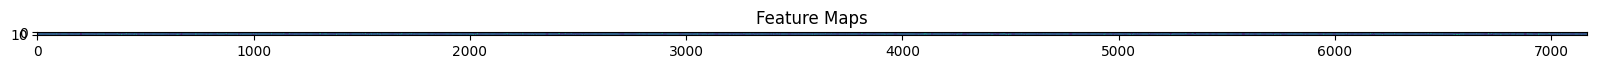

In [274]:
plt.figure(figsize=(scale*no_of_features,scale))
plt.title("Feature Maps")
plt.grid(False)
plt.imshow(display_grid,aspect="auto")

In [275]:
import tensorflow as tf
import numpy as np

In [276]:
base_model=tf.keras.applications.ResNet50(weights="imagenet",include_top=False)
base_model.trainable=False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [277]:
img=tf.keras.preprocessing.image.load_img("/content/drive/MyDrive/ROCO/data/test/radiology/images/ROCO_00446.jpg",target_size=(224,224))

In [278]:
img_array=tf.keras.preprocessing.image.img_to_array(img)
img_array=np.expand_dims(img_array,axis=0)

In [279]:
img_array.shape

(1, 224, 224, 3)

In [280]:
img_array=tf.keras.applications.resnet.preprocess_input(img_array)

In [281]:
img_array.shape

(1, 224, 224, 3)

In [282]:
img_array

array([[[[ -95.939, -108.779, -115.68 ],
         [-103.939, -116.779, -123.68 ],
         [-103.939, -116.779, -123.68 ],
         ...,
         [-103.939, -116.779, -123.68 ],
         [-102.939, -115.779, -122.68 ],
         [ -96.939, -109.779, -116.68 ]],

        [[ -95.939, -108.779, -115.68 ],
         [-103.939, -116.779, -123.68 ],
         [-103.939, -116.779, -123.68 ],
         ...,
         [-102.939, -115.779, -122.68 ],
         [-103.939, -116.779, -123.68 ],
         [ -97.939, -110.779, -117.68 ]],

        [[-102.939, -115.779, -122.68 ],
         [ -99.939, -112.779, -119.68 ],
         [-103.939, -116.779, -123.68 ],
         ...,
         [-102.939, -115.779, -122.68 ],
         [ -98.939, -111.779, -118.68 ],
         [-103.939, -116.779, -123.68 ]],

        ...,

        [[-102.939, -115.779, -122.68 ],
         [-102.939, -115.779, -122.68 ],
         [-102.939, -115.779, -122.68 ],
         ...,
         [-102.939, -115.779, -122.68 ],
         [-102.939, -1

In [283]:
feature_map=base_model(img_array)

In [284]:
feature_map.shape

TensorShape([1, 7, 7, 2048])

ARTIFICIAL NEURAL NETWORK

In [89]:
data = {
    "Title": [
        "Computed tomography scan in axial view showing obliteration of the left maxillary sinus",
        "Bacterial contamination occurred after completion of root canal treatment in the tooth, which remained with a temporary filling for 15 month.",
        "The patient had residual paralysis of the hand after poliomyelitis. It was necessary to stabilize the thumb with reference to the index finger. This was accomplished by placing a graft from the bone bank between the first and second metacarpals. The roentgenogram shows the complete healing of the graft one year later.",
        "Panoramic radiograph after immediate loading.",
        "Plain abdomen x-ray: Multiple air levels at the mid-abdomen (arrows), no radiopaque shadow, and no air under the diaphragm.",
        "A 3-year-old child with visual difficulties. Axial FLAIR image show a supra-sellar lesion extending to the temporal lobes along the optic tracts (arrows) with moderate mass effect, compatible with optic glioma. FLAIR hyperintensity is also noted in the left mesencephalon from additional tumoral involvement",
        "Showing the subtrochanteric fracture in the porotic bone.",
        "Post orthodontic treatment. Root canal therapy done with maxillary incisors",
        "Two sequential thrombi in the distal segment of the obtuse marginal 2 (OM2).",
        "An example of MRI image that takes advantage of joint effusion as contrast material in acute scenario. 57x46mm (150 x 150 DPI).",
        "Child with abduction and flexion of right lower extremity and hyperextension of the tibia on the femur, associated with dislocation of the left hip, probably the result of the dangerous position of adduction in production of pathological dislocation. A roentgenogram of the mother’s pelvis, one week before delivery, showed this same deformity in utero.",
        "Axial T2 HASTE MR image shows loss of normal trilaminar myometrial architecture and mild focal thinning of placenta at the site of compression of myometrium in front of aorta (black arrow), just proximal to the bifurcation. Normal trilaminar signal pattern of myometrium can be seen at other regions (white arrows)",
        "Hydronephrosis appearance in sonography.",
        "Coronary angiogram demonstrating occluded OM1 and OM2 arteries.",
        "Cardiac catheterization showing normal coronaries and a tumor blush.",
        "Follow-up coronary angiography and fluoroscopy showed a gap in the stent strut. A-D: a gap in the stent strut.",
        "Right-sided metatarsal in dorsoplantar projection.Cow. Age group IV—cattle 4–8 years. (a) Narrow symphysis that is (b) indistinct from the bone surface.",
        "Fourth patient’s MRI",
        "Orthopantomograph",
        "Focal steatosis of the liver parenchyma",
        "Preoperative TTE, end diastole (preop pics).",
        "Magnetic resonance T2 weighted image showing foraminal extensions of the cysts",
        "Post-Treatment MRIAxial T1-weighted, contrast-enhanced image showing the same lesion as Figure 3.",
        "Abdominal CT scan showing pancreatic pseudocyst",
        "Axial contrast-enhanced computed tomography image of the abdomen 3 months after anti tuberculous treatment showing complete resolution of the lesions",
        "Lytic lesions (arrows) involving the humerus.",
        "Fluoroscopy image of EVAR procedure.",
        "AP pelvis X-ray obtained 6 weeks from initial presentation which shows early femoral head collapse.",
        "Postoperative control following periapical surgery.",
        "CT image of the liver shows air in the hepatic veins (arrow) and air-contrast level in the inferior vena cava (arrowhead).",
        "SFA perforated after Glidewire insertion in an attempt to cross the lesion.",
        "Postoperative computed tomography scan",
        "18-year-old woman with venous tumor thrombus. Axial T1W fat-saturated, postcontrast MR image of the pelvis.",
        "X-ray control of calcaneus drilling",
        "Transvaginal image of the maternal pelvis demonstrating cervical length. The probe is first advanced into the anterior fornix and then slightly withdrawn so that good image quality is maintained while avoiding placing pressure on the cervix. Cervical length is measured from internal to external os. The endocervical canal is also marked and can be differentiated by its echolucency. The anterior and posterior cervical walls are of similar thickness.",
        "OPG showing a well defined corticated radiolucency containing two supernumerary premolars",
        "Computed tomography scan obtained on December 24, 2014 (7 days before treatment). Notes: Scan demonstrates a mass in the upper lobe of the left lung, multiple enlarged lymph nodes in the mediastinum, and pleural effusion; arrow indicates abundant pericardial effusion around the pericardium.",
        "Coronal contrast chest CT image showing the two aberrant arteries (white arrow) arising directly from the thoracic aorta and the left lower lobe cystic lesion.",
        "Osteoid osteoma in the femur. Axial CT scan shows a nidus (arrow) within the cortex, with surrounding dense sclerosis (arrowhead)",
        "Mandibular occlusal view radiograph showing fusion of mandibular teeth with talon cusp with respect to 41 and 42",
        "Intraoperative T2w MR image showing the tumor and the first BBB target",
        "Free air beneath the diaphragm at abdominal x-ray film",
        "Posteroanterior radiography immediately before reintervention showing the inferior vena caval loop of the pacemaker lead strongly attached to the endothelium. The tip of the electrode is still attached the right ventricular wall. At that time an exit block was predominantly existent.",
        "Après mise en place du drain thoracique",
        "Venography of left innominate vein using catheter introduced via right common femoral vein. The site of perforation is well seen",
        "CT spine showing a mass at level of C3 with marked osseous destruction.",
        "Destroid lung due to progressive pulmonary tuberculosis in a 16-year-old boy. CT scan (lung window) shows diffuse bilateral small and large air-filled cystic lesions (black arrows) associated with ground-glass attenuation and disseminated miliary micronodular lesions on the right (white arrows).",
        "View of giant cell tumor of thumb metacarpal preoperatively.",
        "MRI showing high signals involving the superior sagittal sinus thrombosis on TW1.",
        "Color Doppler echocardiography, parasternal modified short axis view. Middle LAD stenosis was incidentally found on rutine TTE. It was later confirmed by coronary angiography. See movie 13 [see Additional file 13]",
        "Transverse view of lung using computed tomography. Leukemic infiltration is seen."
    ],
    "Label": [
        0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0 ,1 ,0 ,1
    ]
}


In [90]:
import pandas as pd
df=pd.DataFrame(data)
df

,Title,Label
0,Computed tomography scan in axial view showing...,0
1,Bacterial contamination occurred after complet...,1
2,The patient had residual paralysis of the hand...,0
3,Panoramic radiograph after immediate loading.,0
4,Plain abdomen x-ray: Multiple air levels at th...,0
5,A 3-year-old child with visual difficulties. A...,1
6,Showing the subtrochanteric fracture in the po...,0
7,Post orthodontic treatment. Root canal therapy...,0
8,Two sequential thrombi in the distal segment o...,0
9,An example of MRI image that takes advantage o...,0


In [91]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf=TfidfVectorizer(max_features=50)

In [92]:
X=tfidf.fit_transform(df['Title']).toarray()
y=df['Label']

In [94]:
X

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.44962043, 0.        , ..., 0.        , 0.36336235,
        0.        ],
       [0.        , 0.16253471, 0.        , ..., 0.        , 0.13135301,
        0.17191396],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

In [95]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy

In [96]:
model=Sequential([
                Dense(64,activation="relu",input_shape=(X.shape[1],)),
                Dropout(0.5),
                Dense(32,activation="relu"),
                Dense(1,activation="sigmoid")

])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [97]:
model.compile(optimizer=Adam(learning_rate=0.001),loss=BinaryCrossentropy(),metrics=['accuracy'])

In [103]:
model.fit(X,y,epochs=30)

Epoch 1/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9504 - loss: 0.2691
Epoch 2/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9634 - loss: 0.2566
Epoch 3/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8799 - loss: 0.2662
Epoch 4/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9295 - loss: 0.2435
Epoch 5/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9634 - loss: 0.2428
Epoch 6/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9295 - loss: 0.2363 
Epoch 7/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9504 - loss: 0.2253 
Epoch 8/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9165 - loss: 0.2594 
Epoch 9/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9634 - loss: 0.2064 
Epoch 10/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9608 - loss: 0.2118 
Epoch 11/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9765 - loss: 0.1848 
Epoch 12/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9400 - loss: 0.2243 
E

In [104]:
loss,accuracy=model.evaluate(X,y)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9765 - loss: 0.1156 


In [28]:
loss,accuracy

(0.016202401369810104, 1.0)

In [32]:
model.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


array([[9.9974608e-01],
       [6.7774067e-04],
       [9.9957478e-01],
       [6.4229798e-03],
       [1.7636900e-03],
       [9.9941629e-01],
       [9.9897951e-01],
       [1.3238131e-03],
       [9.9896431e-01],
       [7.0235026e-03],
       [9.9928361e-01],
       [4.9978471e-03],
       [9.9532694e-01],
       [9.9947238e-01],
       [9.9919724e-01],
       [7.2173122e-03],
       [6.4518340e-03],
       [9.9814957e-01],
       [9.6629733e-01],
       [9.9563652e-01]], dtype=float32)

RECURRENT NEURAL NETWORK

In [33]:
!pip install faker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 19.0 MB/s eta 0:00:00


In [35]:
from faker import Faker
import numpy as np

In [39]:
fake=Faker()
Faker.seed(42)

In [37]:
def generate_text_labels(num_samples=5000):
  text=[fake.sentence(nb_words=10) for i in range(num_samples)]
  labels=np.random.randint(0,2,num_samples)
  return text,labels

In [40]:
text,labels=generate_text_labels()

In [41]:
text

['Agent every development say quality throughout beautiful.',
 'All behavior discussion own night respond red information last everything thank.',
 'Recently future choice whatever from behavior benefit suggest.',
 'Enough analysis least by two bad fall pick those gun court attorney product.',
 'World talk term herself law street class great prove.',
 'Participant commercial rock clear here writer.',
 'Detail food shoulder argue start source husband at tree note responsibility defense material.',
 'Central cause seat much section investment on gun young catch management.',
 'Technology check civil quite others his.',
 'You more wife team activity result race Mr environment political born itself law.',
 'Will seven medical blood personal success medical current hear.',
 'Much single morning a food affect upon these.',
 'Dream drive note bad rule staff within mouth call.',
 'Water close month parent who up sense ready require human public health.',
 'Later easy ask again network open acc

In [42]:
labels

array([1, 1, 1, ..., 0, 0, 1])

In [44]:
from tensorflow.keras.preprocessing.text import Tokenizer

In [45]:
tokenizer=Tokenizer(num_words=5000)

In [50]:
tokenizer.fit_on_texts(text)

In [51]:
sequences=tokenizer.texts_to_sequences(text)

In [52]:
sequences

[[738, 228, 739, 821, 378, 191, 650],
 [330, 29, 379, 487, 192, 782, 229, 740, 282, 42, 822],
 [230, 30, 331, 117, 741, 29, 231, 22],
 [651, 91, 283, 590, 284, 118, 285, 652, 119, 120, 783, 784, 332],
 [424, 193, 23, 425, 16, 43, 785, 426, 742],
 [333, 956, 286, 121, 334, 743],
 [957, 696, 92, 335, 653, 75, 122, 427, 428, 76, 591, 232, 194],
 [592, 233, 915, 697, 336, 593, 698, 120, 429, 123, 699],
 [744, 870, 700, 195, 337, 338],
 [5, 60, 44, 594, 339, 234, 488, 287, 288, 31, 654, 289, 16],
 [538, 430, 340, 61, 290, 235, 340, 952, 786],
 [697, 45, 964, 431, 696, 871, 936, 432],
 [380, 291, 76, 118, 823, 787, 152, 539, 341],
 [46, 655, 489, 32, 656, 196, 24, 197, 342, 788, 153, 236],
 [490, 491, 492, 62, 595, 824, 343, 745, 237, 2, 330, 596],
 [540, 292, 238, 433, 825, 124, 344, 541, 542, 77, 434, 381],
 [154, 78, 8, 701, 493, 382, 286, 345, 597, 783, 890],
 [33, 42, 63, 746, 383, 744, 93],
 [543, 155, 916, 29, 747, 702],
 [494, 657, 122, 198, 598, 424, 435, 541, 293, 294, 117],
 [332,

In [53]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Pad the sequences to have the same length
padded_sequences = pad_sequences(sequences, padding='post', maxlen=100)

In [54]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(padded_sequences, labels, test_size=0.2, random_state=42)


In [80]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

model = Sequential([
    Embedding(input_dim=5000, output_dim=128, input_length=100),
    LSTM(128, return_sequences=True),
    LSTM(64),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [82]:
model.fit(X_train, y_train, epochs=25, batch_size=32, validation_data=(X_test, y_test))


Epoch 1/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 33s 267ms/step - accuracy: 0.5189 - loss: 0.6952 - val_accuracy: 0.4790 - val_loss: 0.6947
Epoch 2/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 33s 264ms/step - accuracy: 0.5094 - loss: 0.6941 - val_accuracy: 0.4790 - val_loss: 0.6945
Epoch 3/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 41s 266ms/step - accuracy: 0.5092 - loss: 0.6933 - val_accuracy: 0.5210 - val_loss: 0.6923
Epoch 4/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 44s 287ms/step - accuracy: 0.4885 - loss: 0.6938 - val_accuracy: 0.5210 - val_loss: 0.6931
Epoch 5/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 38s 265ms/step - accuracy: 0.4871 - loss: 0.6943 - val_accuracy: 0.4790 - val_loss: 0.6943
Epoch 6/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 33s 264ms/step - accuracy: 0.5100 - loss: 0.6932 - val_accuracy: 0.4790 - val_loss: 0.6996
Epoch 7/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 42s 271ms/step - accuracy: 0.5077 - loss: 0.6934 - val_accuracy: 0.5210 - val_loss: 0.6931
Epoch 8/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 41s 270ms/step - accuracy: 0.5033 - loss: 0

In [84]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Accuracy: {accuracy:.4f}')


32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 127ms/step - accuracy: 0.5027 - loss: 0.6931
Accuracy: 0.5210


In [60]:
predictions = model.predict(X_test)
predicted_labels = (predictions > 0.5).astype('int32')


32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 135ms/step


In [61]:
# New, unseen text data
new_text = ["This is a new sentence.", "Another example of text."]

# Convert new text to sequences using the same tokenizer
new_sequences = tokenizer.texts_to_sequences(new_text)


In [62]:
# Pad the new sequences to the same length as training data
padded_new_sequences = pad_sequences(new_sequences, padding='post', maxlen=100)


In [65]:
# Predict the labels for the new data
predictions = model.predict(padded_new_sequences)

# Convert probabilities to binary labels (0 or 1) using 0.5 threshold
predicted_labels = (predictions > 0.5).astype('int32')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


In [66]:
print(f"Predicted labels: {predicted_labels}")

Predicted labels: [[1]
 [1]]
